# Setup Notebook (Virtual machine)

In this section all required packages will be installed.

In [32]:
!apt-get update
!apt-get install -y swig python3-numpy python3-dev cmake zlib1g-dev libjpeg-dev xvfb ffmpeg xorg-dev python3-opengl libboost-all-dev libsdl2-dev
!pip install gymnasium==1.2.3 gymnasium[box2d] pyvirtualdisplay imageio-ffmpeg moviepy==1.0.3
!pip install onnx onnx2pytorch==0.4.1
# NEW
!pip install onnxscript
!pip install opencv-python pyvirtualdisplay

!wget https://raw.githubusercontent.com/StefOe/colab-pytorch-utils/master/utils.py
import utils


!pip install minigrid==3.0.0

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [33]:
import time
from datetime import datetime
import numpy as np
from collections import deque, namedtuple
import collections
import os
import time
import shutil
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import cv2
import gymnasium as gym
import gymnasium.spaces

import matplotlib.pyplot as plt
import copy
%matplotlib inline
!nvcc --version

from matplotlib import animation
import seaborn as sns; sns.set()
from IPython.display import clear_output, HTML
from IPython import display

import torch.onnx

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


# Mount your drive and use GPU

Here you can mount your GDrive folders (where you will store checkpoints during training).

In [34]:
if not os.path.exists('/content/gdrive'):
    from google.colab import drive
    drive.mount('/content/gdrive')

In [35]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


# Replay Buffer

The replay buffer stores transitions - state, action, reward, next_state.

In [36]:
Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])

class ReplayBuffer():
  def __init__(self, num_actions, memory_len = 10000):
      self.memory_len = memory_len
      self.transition = []
      self.num_actions = num_actions

  def add(self, state, action, reward, next_state, done):
      if self.length() > self.memory_len:
        self.remove()
      self.transition.append(Transition(state, action, reward, next_state, done))

  def sample_batch(self, batch_size = 32):
      minibatch = random.sample(self.transition, batch_size)
      states_mb, a_, reward_mb, next_states_mb, done_mb = map(np.array, zip(*minibatch))

      mb_reward = torch.from_numpy(reward_mb).to(device=device, dtype=torch.float32)
      mb_done = torch.from_numpy(done_mb.astype(int)).to(device=device)
      a_ = a_.astype(int)
      a_mb = np.zeros((a_.size, self.num_actions), dtype=np.float32)
      a_mb[np.arange(a_.size), a_] = 1
      mb_a = torch.from_numpy(a_mb).cuda().to(device=device)
      return states_mb, mb_a, mb_reward, next_states_mb, mb_done # states will be converted to tensors in forward pass

  def length(self):
      return len(self.transition)

  def remove(self):
      self.transition.pop(0)

# MINIGRID DQN-Training

This section contains the train function for the minigrid environment.

### Minigrid Environment and Policy Network





In [37]:
# Minigrid Environment
from minigrid.wrappers import ImgObsWrapper
class ChannelFirst(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        old_shape = env.observation_space.shape
        self.observation_space = {}
        self.observation_space = gym.spaces.Box(0, 255, shape=(3, 7, 7))

    def observation(self, observation):
        return np.swapaxes(observation, 2, 0)

class ScaledFloatFrame(gym.ObservationWrapper):
    def __init__(self, env):
        gym.ObservationWrapper.__init__(self, env)

    def observation(self, observation):
        # careful! This undoes the memory optimization, use
        # with smaller replay buffers only.
        return np.array(observation).astype(np.float32)

class MinigridEmpty5x5ImgObs(gym.Wrapper):
    """Minigrid with image observations provided by minigrid, partially observable."""
    def __init__(self, render=False):
        if render:
          env = gym.make('MiniGrid-Empty-5x5-v0', render_mode="rgb_array")
        else:
          env = gym.make('MiniGrid-Empty-5x5-v0')
        env = ScaledFloatFrame(ChannelFirst(ImgObsWrapper(env)))
        super().__init__(env)

class MinigridDoorKey6x6ImgObs(gym.Wrapper):
    """Minigrid with image observations provided by minigrid, partially observable."""
    def __init__(self, render=False):
        if render:
          env = gym.make('MiniGrid-DoorKey-6x6-v0', render_mode="rgb_array")
        else:
          env = gym.make('MiniGrid-DoorKey-6x6-v0')
        env = ScaledFloatFrame(ChannelFirst(ImgObsWrapper(env)))
        super().__init__(env)

In [38]:
env = MinigridDoorKey6x6ImgObs()
obs = env.reset()[0]
obs, obs.shape, env.action_space

(array([[[0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 2., 2., 2., 0., 0.],
         [0., 0., 2., 1., 2., 0., 0.],
         [0., 0., 2., 5., 2., 0., 0.],
         [0., 0., 4., 1., 2., 0., 0.],
         [0., 0., 2., 1., 2., 0., 0.]],
 
        [[0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 5., 5., 5., 0., 0.],
         [0., 0., 5., 0., 5., 0., 0.],
         [0., 0., 5., 4., 5., 0., 0.],
         [0., 0., 4., 0., 5., 0., 0.],
         [0., 0., 5., 0., 5., 0., 0.]],
 
        [[0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 2., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.]]], dtype=float32),
 (3, 7, 7),
 Discrete(7))

In [39]:
class MlpMinigridPolicy(nn.Module):
    def __init__(self, num_actions=7):
        super().__init__()
        self.num_actions = num_actions
        self.fc = nn.Sequential(nn.Flatten(),
                                nn.Linear(3*7**2, 256), nn.ReLU(),
                                nn.Linear(256, 256), nn.ReLU(),
                                nn.Linear(256, 64), nn.ReLU(),
                                nn.Linear(64, num_actions))
    def forward(self, x):
        if len(x.size()) == 3:
          x = x.unsqueeze(dim=0)
        return self.fc(x)

### Training utils

In [40]:
def plot(frame_idx, rewards, losses):
    clear_output(True)
    plt.figure(figsize=(20,5))
    plt.subplot(131)
    plt.title('frame %s. reward: %s' % (frame_idx, np.mean(rewards[-10:])))
    plt.plot(rewards)
    plt.subplot(132)
    plt.title('loss')
    plt.plot(losses)
    plt.show()

In [41]:
def set_seed(env, seed=None):
    if seed is not None:
        random.seed(seed)
        env.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)


In [42]:
num_episodes = 1500 # number of episodes to run the algorithm -> the algorithm should reach a score of about 0.9 within 1000 episodes # angeapasst auf 1500 von 1000
buffer_size = 100000 # size of the buffer to use
epsilon = 1.0 # initial probablity of selecting random action a, annealed over time
timesteps = 0 # counter for number of frames
minibatch_size = 64 #128 # size of the minibatch sampled #angepasst auf 64 von 5
gamma = 0.99 # discount factor
eval_episode = 50 #angepasst auf 50 von 100
num_eval = 20 #angepasst auf 20 von 10
tau = 1e-3
learning_rate = 0.0001
update_after = 2000 # update after num time steps
epsilon_decay = 50000 # decay epsilon in 100.000 timesteps # angepasst auf 50000 von 10000
epsilon_ub = 1.0
epsilon_lb = 0.05 # angepasst auf 0.05 von 0.3
# set seed
np.random.seed(0)
torch.manual_seed(0)

In [43]:
print(device)

cuda


### Load model (if available)

In [49]:
# specify load path if available:

#load_path = '/content/gdrive/MyDrive/colab-drive/minigrid-model-2022_03_28-10_01_18.p'

load_path = '' # otherwise start with randomly initialized agent

# neu
checkpoint_dir = "/content/gdrive/MyDrive/colab-drive/minigrid_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# save the current model state
save_path = f"/content/gdrive/MyDrive/colab-drive/minigrid-model-{datetime.now().strftime('%Y_%m_%d-%H_%M_%S')}.p"
#save_path = f"minigrid-model-{datetime.now().strftime('%Y_%m_%d-%H_%M_%S')}.p"

print(f'model checkpoints will be saved to: {save_path}')

def load_checkpoint(checkpoint_path='', device=device):
  dqn = MlpMinigridPolicy(num_actions=num_actions).to(device=device)
  dqn_target = MlpMinigridPolicy(num_actions=num_actions).to(device=device)
  timesteps = 0

  if checkpoint_path:
    print(f'Loading checkpoint {checkpoint_path}')
    checkpoint_dict = torch.load(checkpoint_path, map_location=device)
    model_params = checkpoint_dict['model_params']
    timesteps = checkpoint_dict['timesteps'] # environment steps

    dqn.load_state_dict(model_params) # makes a copy of model_params
    dqn_target.load_state_dict(model_params)
  else:
    print(f'Starting training from scratch.')

  return dqn, dqn_target, timesteps

def store_checkpoint(checkpoint_path, dqn_net, timesteps):
  checkpoint_dict = {'model_params':dqn_net.state_dict(), 'timesteps': timesteps}
  torch.save(checkpoint_dict, checkpoint_path)

model checkpoints will be saved to: /content/gdrive/MyDrive/colab-drive/minigrid-model-2026_04_07-18_25_01.p


In [50]:
# Initialize environment

# VERY IMPORTANT:
# Fast environment to build your code: MinigridEmpty5x5ImgObs() <- Train on this to improve your code fast.
# Actual environment for the exercise: MinigridDoorKey6x6ImgObs() <- Train on this for submitting on challenge server.
# Make sure to train on the right environment, when you are submitting your model.

env = MinigridDoorKey6x6ImgObs()

num_actions = env.action_space.n
state_space = env.observation_space.shape
print(num_actions, state_space)
obs, obs.shape, env.action_space

7 (3, 7, 7)


(array([[[0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 2., 2., 2., 0., 0.],
         [0., 0., 2., 1., 2., 0., 0.],
         [0., 0., 2., 5., 2., 0., 0.],
         [0., 0., 4., 1., 2., 0., 0.],
         [0., 0., 2., 1., 2., 0., 0.]],
 
        [[0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 5., 5., 5., 0., 0.],
         [0., 0., 5., 0., 5., 0., 0.],
         [0., 0., 5., 4., 5., 0., 0.],
         [0., 0., 4., 0., 5., 0., 0.],
         [0., 0., 5., 0., 5., 0., 0.]],
 
        [[0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 2., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.]]], dtype=float32),
 (3, 7, 7),
 Discrete(7))

In [51]:
# Update Target network
def soft_update(local_model, target_model, tau):
    """Soft update model parameters.
    θ_target = τ*θ_local + (1 - τ)*θ_target
    Params
    ======
        local_model (PyTorch model): weights will be copied from
        target_model (PyTorch model): weights will be copied to
        tau (float): interpolation parameter
    """
    # TODO: Update target network

    # Soft-update for all parameters
    for target_param, local_param in zip(target_model.parameters(), local_model.parameters()):
        target_param.data.copy_(tau * local_param.data + (1.0 - tau) * target_param.data)

### DQN training loop

In [52]:
from torch.serialization import load

# Train the agent using DQN for Pong
returns = []
returns_50 = deque(maxlen=50)
losses = []
buffer = ReplayBuffer(num_actions=num_actions, memory_len=buffer_size)

dqn, dqn_target, timesteps = load_checkpoint(load_path)

optimizer = optim.Adam(dqn.parameters(), lr=learning_rate)
mse = torch.nn.MSELoss()
state = env.reset()[0]
for i in range(num_episodes):
  ret = 0
  done = False
  while not done:
    # Decay epsilon
    epsilon = max(epsilon_lb, epsilon_ub - timesteps/ epsilon_decay)
    # action selection
    if np.random.choice([0,1], p=[1-epsilon,epsilon]) == 1:
      a = np.random.randint(low=0, high=num_actions, size=1)[0]
    else:
      # state_tmp = state[np.newaxis, :].astype(np.float32)
      state_tensor = torch.tensor(state, dtype=torch.float32, device=device)
      net_out = dqn(state_tensor).detach().cpu().numpy()
      a = np.argmax(net_out)
#    next_state, r, done, info = env.step(a)
    next_state, r, terminated, truncated, info = env.step(a)
    done = terminated or truncated
#    print(next_state.shape)
    ret = ret + r
    # TODO: store transition in replay buffer

    # store transition in replay buffer
    buffer.add(state, a, r, next_state, done)

    state = next_state
    timesteps = timesteps + 1

    # update policy using temporal difference
    if buffer.length() > minibatch_size and buffer.length() > update_after:
      optimizer.zero_grad()
      # TODO: Sample a minibatch randomly

      # Sample a minibatch randomly
      states_mb, actions_mb, rewards_mb, next_states_mb, done_mb = buffer.sample_batch(minibatch_size)

      # TODO: Compute q values for states

      # Compute q values for states
      states_tensor = torch.tensor(states_mb, dtype=torch.float32, device=device)
      next_states_tensor = torch.tensor(next_states_mb, dtype=torch.float32, device=device)

      q_values = dqn(states_tensor)
      next_q_values_target = dqn_target(next_states_tensor).detach()

      # TODO: compute the targets for training

      # Compute the targets for training
      max_next_q_values = torch.max(next_q_values_target, dim=1)[0]
      targets = rewards_mb + gamma * max_next_q_values * (1 - done_mb.float())

      # TODO: compute the predictions for training

      # Compute the predictions for training
      predictions = torch.sum(q_values * actions_mb, dim=1)

      # TODO: Compute loss: mse = mean squared error

      # Compute loss: mse = mean squared error
      loss = mse(predictions, targets)

      # print('predictions', predictions, 'targets', targets)
      # print(loss)
      loss.backward()
      optimizer.step()
      losses.append(loss.item())

      # Update target network
      soft_update(dqn, dqn_target, tau)
    if done:
      state = env.reset()[0]
      print(f"Episode: \t{i}\t{ret}\t{datetime.now().strftime('%Y_%m_%d-%H_%M_%S')}")
      break
  returns.append(ret)
  returns_50.append(ret)
  # alt
  #if i % 50 == 0:
    #store_checkpoint(checkpoint_path=save_path, dqn_net=dqn, timesteps=timesteps)
    #print('\rEpisode {}\tAverage Score: {:.2f}'.format(i, np.mean(returns_50)))

  # neu
  if i % 50 == 0:
    checkpoint_path = f"{checkpoint_dir}/checkpoint_ep_{i:04d}.p"
    store_checkpoint(checkpoint_path=checkpoint_path, dqn_net=dqn, timesteps=timesteps)

    print(f"Episode {i}\tAverage Score: {np.mean(returns_50):.3f}")
    print(f"Checkpoint gespeichert: {checkpoint_path}")

Starting training from scratch.
Episode: 	0	0	2026_04_07-18_25_14
Episode 0	Average Score: 0.000
Checkpoint gespeichert: /content/gdrive/MyDrive/colab-drive/minigrid_checkpoints/checkpoint_ep_0000.p
Episode: 	1	0	2026_04_07-18_25_14
Episode: 	2	0	2026_04_07-18_25_14
Episode: 	3	0	2026_04_07-18_25_14
Episode: 	4	0	2026_04_07-18_25_14
Episode: 	5	0	2026_04_07-18_25_15
Episode: 	6	0	2026_04_07-18_25_16
Episode: 	7	0	2026_04_07-18_25_18
Episode: 	8	0	2026_04_07-18_25_20
Episode: 	9	0	2026_04_07-18_25_21
Episode: 	10	0	2026_04_07-18_25_22
Episode: 	11	0.6825	2026_04_07-18_25_23
Episode: 	12	0.1974999999999999	2026_04_07-18_25_24
Episode: 	13	0	2026_04_07-18_25_25
Episode: 	14	0	2026_04_07-18_25_26
Episode: 	15	0	2026_04_07-18_25_28
Episode: 	16	0	2026_04_07-18_25_29
Episode: 	17	0	2026_04_07-18_25_30
Episode: 	18	0	2026_04_07-18_25_32
Episode: 	19	0	2026_04_07-18_25_34
Episode: 	20	0	2026_04_07-18_25_35
Episode: 	21	0	2026_04_07-18_25_36
Episode: 	22	0	2026_04_07-18_25_37
Episode: 	23	0	202

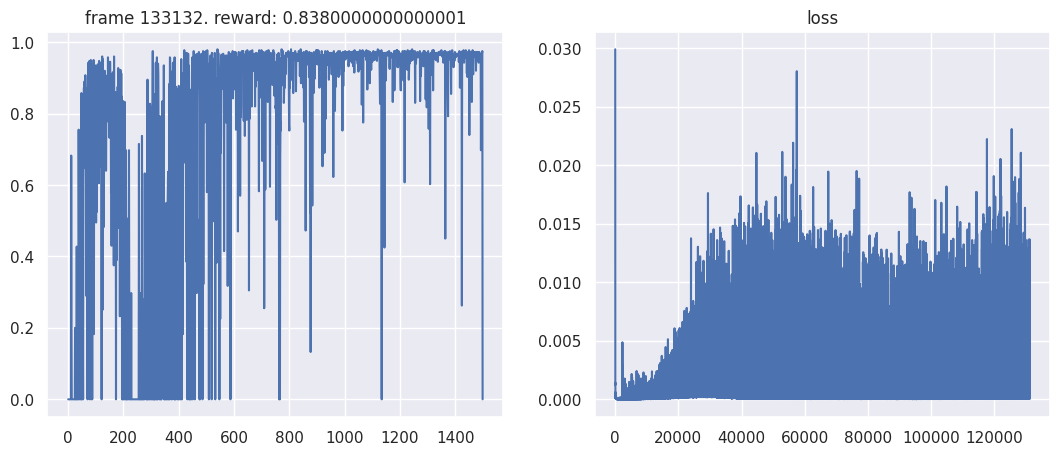

In [53]:
plot(timesteps, returns, losses)

Evaluate your model:

In [54]:
class Agent():
    def __init__(self, model, device):
        self.model = model
        self.device = device

    def select_action(self, state):
        state = np.expand_dims(state, 0)
        state = torch.tensor(state, dtype=torch.float32, device=self.device)
        with torch.no_grad():
            q_action = self.model(state).detach().cpu().numpy()

            return np.argmax(q_action)

def run_episode(env, agent, seed=None):
    state = env.reset(seed=seed)[0]
    score = 0
    done = False
    while not done:
        action = agent.select_action(state)
        state, reward, terminated, truncated, _ = env.step(action)
        score += reward
        done = terminated or truncated
    env.close()
    return score

# NEU
def evaluate_agent(env_fn, model, device, n_episodes=20):
    model.eval()
    agent = Agent(model=model, device=device)
    scores = []

    for _ in range(n_episodes):
        eval_env = env_fn()
        seed = np.random.randint(1e7)
        scores.append(run_episode(eval_env, agent, seed=seed))

    model.train()
    return float(np.mean(scores))

In [55]:
import glob
# NEU

checkpoint_paths = sorted(glob.glob(f"{checkpoint_dir}/checkpoint_ep_*.p"))

print("Gefundene Checkpoints:")
for p in checkpoint_paths:
    print(p)

Gefundene Checkpoints:
/content/gdrive/MyDrive/colab-drive/minigrid_checkpoints/checkpoint_ep_0000.p
/content/gdrive/MyDrive/colab-drive/minigrid_checkpoints/checkpoint_ep_0050.p
/content/gdrive/MyDrive/colab-drive/minigrid_checkpoints/checkpoint_ep_0100.p
/content/gdrive/MyDrive/colab-drive/minigrid_checkpoints/checkpoint_ep_0150.p
/content/gdrive/MyDrive/colab-drive/minigrid_checkpoints/checkpoint_ep_0200.p
/content/gdrive/MyDrive/colab-drive/minigrid_checkpoints/checkpoint_ep_0250.p
/content/gdrive/MyDrive/colab-drive/minigrid_checkpoints/checkpoint_ep_0300.p
/content/gdrive/MyDrive/colab-drive/minigrid_checkpoints/checkpoint_ep_0350.p
/content/gdrive/MyDrive/colab-drive/minigrid_checkpoints/checkpoint_ep_0400.p
/content/gdrive/MyDrive/colab-drive/minigrid_checkpoints/checkpoint_ep_0450.p
/content/gdrive/MyDrive/colab-drive/minigrid_checkpoints/checkpoint_ep_0500.p
/content/gdrive/MyDrive/colab-drive/minigrid_checkpoints/checkpoint_ep_0550.p
/content/gdrive/MyDrive/colab-drive/minig

In [56]:
# NEU
checkpoint_scores = []

best_score = -1.0
best_path = None

N_EVAL_EPISODES = 50

for checkpoint_path in checkpoint_paths:
    print(f"Teste Checkpoint: {checkpoint_path}")

    model, _, _ = load_checkpoint(checkpoint_path, device=device)
    model.eval()

    agent = Agent(model=model, device=device)

    scores = []
    for i in range(N_EVAL_EPISODES):
        eval_env = MinigridDoorKey6x6ImgObs()
        seed = np.random.randint(1e7)
        scores.append(run_episode(eval_env, agent, seed=seed))

    avg_score = float(np.mean(scores))
    checkpoint_scores.append((checkpoint_path, avg_score))

    print(f"Average Return: {avg_score:.3f}")

    if avg_score > best_score:
        best_score = avg_score
        best_path = checkpoint_path

print("\nBestes Modell gefunden:")
print("Pfad:", best_path)
print("Score:", best_score)

Teste Checkpoint: /content/gdrive/MyDrive/colab-drive/minigrid_checkpoints/checkpoint_ep_0000.p
Loading checkpoint /content/gdrive/MyDrive/colab-drive/minigrid_checkpoints/checkpoint_ep_0000.p
Average Return: 0.000
Teste Checkpoint: /content/gdrive/MyDrive/colab-drive/minigrid_checkpoints/checkpoint_ep_0050.p
Loading checkpoint /content/gdrive/MyDrive/colab-drive/minigrid_checkpoints/checkpoint_ep_0050.p
Average Return: 0.059
Teste Checkpoint: /content/gdrive/MyDrive/colab-drive/minigrid_checkpoints/checkpoint_ep_0100.p
Loading checkpoint /content/gdrive/MyDrive/colab-drive/minigrid_checkpoints/checkpoint_ep_0100.p
Average Return: 0.349
Teste Checkpoint: /content/gdrive/MyDrive/colab-drive/minigrid_checkpoints/checkpoint_ep_0150.p
Loading checkpoint /content/gdrive/MyDrive/colab-drive/minigrid_checkpoints/checkpoint_ep_0150.p
Average Return: 0.058
Teste Checkpoint: /content/gdrive/MyDrive/colab-drive/minigrid_checkpoints/checkpoint_ep_0200.p
Loading checkpoint /content/gdrive/MyDrive/c

In [57]:
#N_EPISODES = 50
#agent = Agent(model=dqn, device=device)

#scores = []
#for i in range(N_EPISODES):
    #seed = np.random.randint(1e7)
    #scores.append(run_episode(env, agent, seed=seed))

# Print result
#print("Average Return:", np.mean(scores))

In [58]:
# NEU

best_model_final_path = "/content/gdrive/MyDrive/colab-drive/best_minigrid_model.p"

best_dqn, _, best_timesteps = load_checkpoint(best_path, device=device)
store_checkpoint(best_model_final_path, best_dqn, best_timesteps)

print("Bestes Modell separat gespeichert unter:")
print(best_model_final_path)

Loading checkpoint /content/gdrive/MyDrive/colab-drive/minigrid_checkpoints/checkpoint_ep_1350.p
Bestes Modell separat gespeichert unter:
/content/gdrive/MyDrive/colab-drive/best_minigrid_model.p


In [59]:
# NEU

best_dqn, _, _ = load_checkpoint(best_model_final_path, device=device)
best_dqn.eval()

agent = Agent(model=best_dqn, device=device)

scores = []
N_EPISODES = 50

for i in range(N_EPISODES):
    eval_env = MinigridDoorKey6x6ImgObs()
    seed = np.random.randint(1e7)
    scores.append(run_episode(eval_env, agent, seed=seed))

print("Average Return des besten Modells:", np.mean(scores))

Loading checkpoint /content/gdrive/MyDrive/colab-drive/best_minigrid_model.p
Average Return des besten Modells: 0.92925


Convert model to ONNX for Submission:

In [60]:
def save_as_onnx(torch_model, sample_input, model_path):
    torch.onnx.export(torch_model,             # model being run
                    sample_input,              # model input (or a tuple for multiple inputs)
                    f=model_path,              # where to save the model (can be a file or file-like object)
                    export_params=True,        # store the trained parameter weights inside the model file
                    opset_version=17,          # the ONNX version to export the model to - see https://github.com/microsoft/onnxruntime/blob/master/docs/Versioning.md
                    do_constant_folding=True,  # whether to execute constant folding for optimization
                    external_data=False,       # keeps everything in a single .onnx file, needed if you are using torch version 2.5 or newer, comment out otherwise
                    )

In [61]:
# NEU

onnx_path = "/content/gdrive/MyDrive/colab-drive/submission_model_new.onnx"

sample_state = env.reset(seed=0)[0]
sample_input = torch.tensor(sample_state, dtype=torch.float32, device=device).unsqueeze(0)

save_as_onnx(best_dqn, sample_input, onnx_path)
print("ONNX gespeichert unter:", onnx_path)

W0407 18:41:55.934000 849 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `MlpMinigridPolicy([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MlpMinigridPolicy([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX gespeichert unter: /content/gdrive/MyDrive/colab-drive/submission_model_new.onnx


In [62]:
#sample_state = env.reset(seed=seed)[0]
#save_as_onnx(dqn, torch.tensor(sample_state, dtype=torch.float32, device=device), 'submission_model_new.onnx')

In [67]:
# load the onnx model and test it:
import onnx
from onnx2pytorch import ConvertModel

#dqn = ConvertModel(onnx.load('submission_model_new.onnx'))
#dqn = dqn.to(device)
onnx_model = onnx.load(onnx_path)
dqn = ConvertModel(onnx_model).to(device)
dqn.eval()

agent = Agent(model=dqn, device=device)

scores = []
for i in range(N_EPISODES):
    seed = np.random.randint(1e7)
    scores.append(run_episode(env, agent, seed=seed))


print("Average Return:", np.mean(scores))

Average Return: 0.91035
